In [2]:
pip install gradio


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pandas seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load Titanic Dataset
url = r'/Users/nitinkumar/Desktop/april(2025)/3th- EDA Automation Mistral, gradio/3th- EDA Automation Mistral, gradio/titanic_ dataset_final.csv'
df =pd.read_csv(url)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# Display dataset info
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
# Missing Values Check
print('\n Missing Values:\n',df.isnull().sum())


 Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


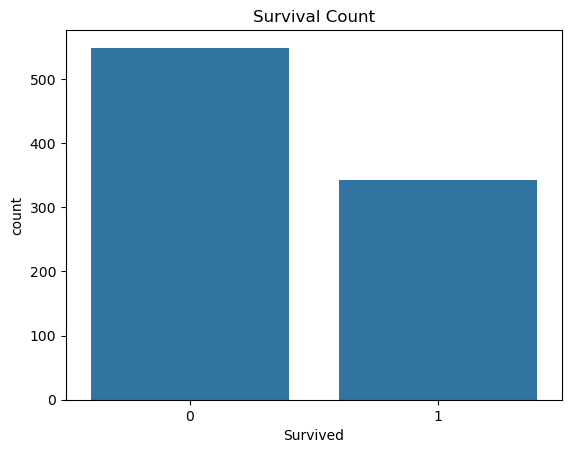

In [ ]:
# Survival Rate Visualization
sns.countplot(x='Survived',data=df)
plt.title('Survival Count')
plt.show()

In [ ]:
import ollama

def generate_insights(df_summary):
    prompt = f" Analyze the dataset summary and provide insights:\n\n{df_summary}"
    response = ollama.chat(model="mistral:7b ", messages=[{"role":"user", "content":prompt}])
    return response['message']['content']
# Generate AI Insights
summary=df.describe().to_string()
insights = generate_insights(summary)
print("\n+ AI-Generated Insights:\n",insights)


+ AI-Generated Insights:
  This dataset is likely from the Titanic disaster, as indicated by the variable names and the fact that the maximum number of passengers (891) matches the total number of people aboard the Titanic. Here are some insights derived from the summary:

1. The majority of the passengers (mean = 446) did not survive the sinking (Survived column shows 0). Only about one-third survived, which aligns with the well-known facts about the disaster.

2. The mean Pclass is 2.3, indicating a mix of first, second, and third-class passengers. First class would have a Pclass value of 1, second class 2, and third class 3. Most passengers were from third class (meaning they had the least privileged tickets), which aligns with the general makeup of passengers on the Titanic.

3. The mean age is 29.69 years old. The minimum age is 0.42, suggesting that some infants were also aboard the ship. It's interesting to note that this dataset does not include ages below 1 year old.

4. The 

In [15]:

import gradio as gr

def eda_analysis(file):
    df = pd.read_csv(file.name)
    summary = df.describe().to_string()
    insights = generate_insights(summary)
    return insights

# Create Web Interface
demo = gr.Interface(fn=eda_analysis, inputs="file", outputs="text", title="AI-Powered EDA with Mistral")

# Launch App
demo.launch(share=True)  

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: /Users/nitinkumar/.cache/huggingface/gradio/frpc/frpc_darwin_arm64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_darwin_arm64
2. Rename the downloaded file to: frpc_darwin_arm64_v0.3
3. Move the file to this location: /Users/nitinkumar/.cache/huggingface/gradio/frpc


/opt/anaconda3/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Error while flagging: [Errno 30] Read-only file system: '.gradio'
